# Avance 2 — Ingeniería de Características: LADDER Attack Pattern Dataset
**Proyecto:** LADDER — *Looking Beyond IoCs* (RAID 2023)
**Datasets:** `sentence_classification` · `entity_extraction` · `attack-pattern-matching-gt`
**Entorno:** Google Colab / Local
**Equipo:** Team 11

Integrantes:

* A01796095 Alicia Canta Pandal
* A01328387 Miguel Silva Ramos
* A01370358 Marco Antonio Corona Ruiz


> Este notebook aborda la fase de **Ingeniería de Características (Feature Engineering)** dentro de la metodología CRISP-ML(Q).
> Se incluye la generación de una nueva variable continua `threat_composite_score` basada en el framework MITRE ATT&CK,
> así como operaciones de codificación, escalamiento, transformación y selección de características.

### Contexto de negocio y justificación de la nueva variable

---

#### ¿Por qué es necesaria una variable de severidad en inteligencia de amenazas?

En el contexto empresarial de ciberseguridad, los equipos de **SOC (Security Operations Center)** enfrentan
diariamente miles de alertas de seguridad. Según IBM (2024), el costo promedio global de una brecha de datos
alcanzó **USD 4.88 millones** en 2024, un aumento del 10% respecto al año anterior.

El problema central es la **priorización**: sin una métrica cuantitativa de severidad, los analistas
deben evaluar manualmente cada alerta, lo que genera:

| Problema | Impacto real |
|---|---|
| **Fatiga de alertas** | El 62% de los analistas SOC reportan burnout por exceso de alertas (Tines, 2023) |
| **Tiempo medio de detección (MTTD)** | 204 días promedio para identificar una brecha (IBM, 2024) |
| **Falsos positivos** | Hasta el 45% de las alertas son falsos positivos (Ponemon Institute, 2023) |
| **Priorización incorrecta** | Ataques de alto impacto pasan desapercibidos mientras se investigan alertas menores |

#### Casos reales donde la severidad cuantificada aporta valor

1. **SolarWinds (2020)**: El ataque APT encadenó técnicas de *Initial Access → Persistence →
   Defense Evasion → Collection → Exfiltration*. Una variable de severidad compuesta habría
   escalado automáticamente la prioridad al detectar técnicas multi-táctica cruzando fases
   avanzadas del kill chain (CISA, 2021).

2. **Colonial Pipeline (2021)**: El ransomware DarkSide combinó *Credential Access → Lateral
   Movement → Impact*. Un `threat_composite_score` alto habría activado respuesta inmediata
   al detectar la progresión hacia tácticas de impacto (Dragos, 2021).

3. **MOVEit Transfer (2023)**: Explotación masiva que afectó a 2,500+ organizaciones. La técnica
   combinaba *Initial Access + Exfiltration*, generando un score compuesto elevado que
   facilitaría la triaje automática (Mandiant, 2023).

#### ¿Cómo aporta valor el `threat_composite_score`?

| Beneficio | Descripción |
|---|---|
| **Triaje automático** | Permite ordenar alertas por severidad cuantitativa, reduciendo MTTD |
| **Priorización basada en riesgo** | Alinea recursos de defensa con las técnicas de mayor impacto potencial |
| **Detección de APTs** | Técnicas multi-táctica (score alto por versatilidad) son indicadores de ataques avanzados |
| **Input para modelos ML** | Variable continua ideal para alimentar modelos predictivos de detección de amenazas |
| **Cumplimiento regulatorio** | Frameworks como NIST CSF 2.0 requieren priorización basada en riesgo cuantificado |

## 0. Instalación de dependencias y carga de datos

In [ ]:
!pip install pandas matplotlib seaborn scikit-learn -q

from pathlib import Path
from collections import Counter
import csv, re, warnings, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold, chi2, f_classif
from scipy.stats import boxcox

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white"})

# Detección de entorno
if Path("/content").exists():
    BASE = Path("/content")
    print("Entorno: Google Colab detectado.")
else:
    posibles_rutas = [Path("../attack_pattern/data"), Path("./attack_pattern/data"), Path("attack_pattern/data")]
    BASE = Path(".")
    for p in posibles_rutas:
        if (p / "sentence_classification").exists():
            BASE = p
            break
    print(f"Entorno local detectado. Base: {BASE.absolute()}")

SC_DIR  = BASE / "sentence_classification"
EE_DIR  = BASE / "entity_extraction"
AP_PATH = BASE / "attack-pattern-matching-gt.csv"

def load_sc(path):
    df = pd.read_csv(path, sep="\t", encoding="utf-8")
    df["label"] = df["label"].astype(str)
    df["word_count"] = df["text"].str.split().str.len()
    df["char_count"] = df["text"].str.len()
    return df

def load_ee_tokens(path):
    rows, sents, cur = [], [], []
    with open(path, encoding="utf-8", errors="replace") as f:
        for raw in f:
            line = raw.rstrip("\n")
            if not line.strip():
                if cur: sents.append(cur); cur = []
                continue
            parts = line.rsplit(" ", 1)
            if len(parts) == 2:
                cur.append(parts)
    if cur: sents.append(cur)
    for i, s in enumerate(sents):
        for t, l in s:
            rows.append({"token": t, "label": l, "sent_id": i, "sent_len": len(s)})
    return pd.DataFrame(rows), sents

sc = {s: load_sc(SC_DIR / f"{s}.csv") for s in ("train","dev","test")}
ee, ee_sents = {}, {}
for s in ("train","dev","test"):
    ee[s], ee_sents[s] = load_ee_tokens(EE_DIR / f"{s}.txt")
ap = pd.read_csv(AP_PATH)
ap["word_count"] = ap["text"].str.split().str.len()

print("Datos cargados:")
for s in ("train","dev","test"):
    print(f"  SC[{s}]: {len(sc[s])} filas | EE[{s}]: {ee[s]['sent_id'].nunique()} oraciones / {len(ee[s])} tokens")
print(f"  AP ground-truth: {len(ap)} filas")

Entorno local detectado. Base: d:\code\master\IntegratorProject\dataset\LADDER\PI_team11\..\attack_pattern\data
Datos cargados:
  SC[train]: 2214 filas | EE[train]: 1144 oraciones / 25443 tokens
  SC[dev]: 568 filas | EE[dev]: 308 oraciones / 7101 tokens
  SC[test]: 662 filas | EE[test]: 348 oraciones / 6490 tokens
  AP ground-truth: 81 filas


## A. Generación de nuevas características

### A.1 Nueva variable: `threat_composite_score` (Índice Compuesto de Severidad de Amenaza)

---

#### Contexto y estado del arte

MITRE ATT&CK es el framework estándar para describir comportamientos adversarios en ciberseguridad. Organiza las
acciones de los atacantes en **tácticas** (el *por qué*) y **técnicas** (el *cómo*). Cada técnica pertenece a una
o más tácticas, que representan fases del ciclo de ataque.

Un hallazgo clave de la revisión bibliográfica es que **MITRE ATT&CK intencionalmente no asigna puntuaciones de
severidad a sus técnicas** (Strom et al., 2018). Esto se debe a que la severidad depende del contexto organizacional.
Sin embargo, la literatura propone varias metodologías para cuantificar el riesgo:

| Enfoque | Descripción | Fuente |
|---|---|---|
| Severidad por Táctica (Kill Chain Phase) | Asignar severidad según la posición de la táctica en la cadena de ataque | MITRE Center for Threat-Informed Defense (2023) |
| Prevalencia | Frecuencia de uso de la técnica en reportes de amenazas reales | Red Canary (2024); MITRE Top Techniques |
| Puntos de Estrangulamiento | Centralidad de la técnica como cuello de botella en grafos de ataque | Xiong et al. (2022) |
| Scoring Multivariado Compuesto | Agregar múltiples dimensiones de riesgo en un único score | Dark Reading (2025); IEEE (2024) |
| MCDM (Multi-Criteria Decision-Making) | Métodos PROMETHEE/MOORA para priorizar técnicas | Kure et al. (2022) |

---

#### ¿Por qué un score *compuesto* y *continuo*?

En el contexto actual, donde la **inteligencia artificial potencia la sofisticación y velocidad de los ciberataques**
(MIT, 2025; IEEE, 2024), los modelos de scoring unidimensionales resultan insuficientes. Los adversarios modernos —
especialmente APTs asistidos por IA — encadenan técnicas que cruzan *múltiples tácticas simultáneamente*, lo que
amplifica el riesgo de forma no lineal.

**Propuesta: Composite Threat Score (CTS)**

Para cada técnica $t$ en el dataset, definimos:

$$\text{CTS}(t) = \alpha \cdot \max(W_t) + \beta \cdot \overline{W_t} + \gamma \cdot V(t)$$

Donde:
- $W_t = \{w_{\tau} : \tau \in \text{tactics}(t)\}$ son los pesos normalizados de las tácticas asociadas a $t$
- $\max(W_t)$ = peso de la táctica más severa (worst-case)
- $\overline{W_t}$ = promedio de pesos tácticos (severidad media a lo largo del kill chain)
- $V(t) = \frac{|\text{tactics}(t)|}{T_{\max}}$ = factor de versatilidad (proporción de tácticas cubiertas)
- $\alpha = 0.50$, $\beta = 0.30$, $\gamma = 0.20$ (coeficientes de ponderación)

**Justificación de los coeficientes:**
- **α = 0.50**: El peor escenario tiene el mayor peso, alineándose con el principio de defensa en profundidad.
- **β = 0.30**: El promedio captura la amplitud del riesgo a través de múltiples fases de ataque.
- **γ = 0.20**: La versatilidad penaliza técnicas multi-táctica, reflejando que en la era de la IA,
  los adversarios reutilizan técnicas como pivotes entre fases del kill chain (Dark Reading, 2025).

---

#### Pesos tácticos (Kill Chain Phase Weights)

Los pesos se asignan de forma **continua normalizada [0,1]** según la posición en el ciclo de ataque
y el potencial de impacto directo:

| Táctica | Descripción | Peso ($w$) | Justificación |
|---|---|---|---|
| Reconnaissance | Recopilar información | 0.10 | Fase preparatoria, bajo impacto directo |
| Resource Development | Establecer infraestructura | 0.15 | Soporte logístico |
| Initial Access | Obtener acceso al dispositivo | 0.25 | Punto de entrada, criticidad moderada |
| Execution | Ejecutar código malicioso | 0.40 | Habilitador de todas las fases posteriores |
| Persistence | Mantener presencia | 0.45 | Garantiza continuidad del ataque |
| Privilege Escalation | Obtener permisos elevados | 0.60 | Acceso a recursos protegidos |
| Defense Evasion | Evadir detección | 0.55 | Habilita persistencia prolongada |
| Credential Access | Robar credenciales | 0.65 | Acceso a identidades y datos sensibles |
| Discovery | Explorar el entorno | 0.35 | Inteligencia interna, severidad moderada |
| Lateral Movement | Moverse por la red | 0.50 | Expansión del ataque |
| Collection | Recopilar datos objetivo | 0.70 | Pre-exfiltración, alto impacto |
| Command and Control | Canal de comunicación C2 | 0.55 | Infraestructura de control |
| Exfiltration | Extraer datos robados | 0.85 | Daño directo a confidencialidad |
| Impact | Destruir/manipular/interrumpir | 0.95 | Máximo daño operacional |

####Nota metodológica sobre la elección de pesos:
Los coeficientes α=0.50, β=0.30, γ=0.20 fueron asignados mediante juicio experto basado en los principios de defensa en profundidad. Si bien este enfoque es válido para un prototipo de ingeniería de características, el estado del arte propone métodos más objetivos para derivar pesos. Abo-Alian et al. (2025) demuestran que el Entropy Weight Method (EWM) — un método de asignación de pesos basado en la varianza informacional de los datos — elimina la subjetividad del proceso y produce resultados reproducibles y data-driven.

In [ ]:
# ──────────────────────────────────────────────────────────
# A.1  Definición del mapeo técnica → tácticas (MITRE ATT&CK Mobile)
# Fuente: https://attack.mitre.org/matrices/mobile/
# ──────────────────────────────────────────────────────────

# Pesos tácticos normalizados (kill chain phase weight)
TACTIC_WEIGHTS = {
    "Reconnaissance":        0.10,
    "Resource Development":  0.15,
    "Initial Access":        0.25,
    "Execution":             0.40,
    "Persistence":           0.45,
    "Privilege Escalation":  0.60,
    "Defense Evasion":       0.55,
    "Credential Access":     0.65,
    "Discovery":             0.35,
    "Lateral Movement":      0.50,
    "Collection":            0.70,
    "Command and Control":   0.55,
    "Exfiltration":          0.85,
    "Impact":                0.95,
}

# Mapeo: technique_id → {name, tactics} (MITRE ATT&CK Mobile Matrix)
TECHNIQUE_MAP = {
    "T1404": {"name": "Exploit OS Vulnerability",            "tactics": ["Privilege Escalation"]},
    "T1406": {"name": "Obfuscated Files or Information",     "tactics": ["Defense Evasion"]},
    "T1407": {"name": "Download New Code at Runtime",        "tactics": ["Defense Evasion", "Execution"]},
    "T1409": {"name": "Stored Application Data",             "tactics": ["Collection"]},
    "T1417": {"name": "Input Capture",                       "tactics": ["Collection", "Credential Access"]},
    "T1418": {"name": "Software Discovery",                  "tactics": ["Discovery"]},
    "T1423": {"name": "Network Service Scanning",            "tactics": ["Discovery"]},
    "T1428": {"name": "Exploitation of Remote Services",     "tactics": ["Lateral Movement"]},
    "T1429": {"name": "Audio Capture",                       "tactics": ["Collection"]},
    "T1430": {"name": "Location Tracking",                   "tactics": ["Collection", "Discovery"]},
    "T1456": {"name": "Drive-By Compromise",                 "tactics": ["Initial Access"]},
    "T1458": {"name": "Replication Through Removable Media", "tactics": ["Initial Access", "Lateral Movement"]},
    "T1461": {"name": "Lockscreen Bypass",                   "tactics": ["Defense Evasion", "Privilege Escalation"]},
    "T1481": {"name": "Web Service",                         "tactics": ["Command and Control"]},
    "T1512": {"name": "Video Capture",                       "tactics": ["Collection"]},
    "T1513": {"name": "Screen Capture",                      "tactics": ["Collection"]},
    "T1517": {"name": "Access Notifications",                "tactics": ["Collection"]},
    "T1541": {"name": "Foreground Persistence",              "tactics": ["Persistence"]},
    "T1577": {"name": "Compromise Application Executable",   "tactics": ["Persistence"]},
    "T1582": {"name": "SMS Control",                         "tactics": ["Impact", "Collection"]},
    "T1623": {"name": "Command and Scripting Interpreter",   "tactics": ["Execution"]},
    "T1628": {"name": "Hide Artifacts",                      "tactics": ["Defense Evasion"]},
    "T1629": {"name": "Impair Defenses",                     "tactics": ["Defense Evasion"]},
    "T1630": {"name": "Indicator Removal on Host",           "tactics": ["Defense Evasion"]},
    "T1634": {"name": "Credentials from Password Stores",    "tactics": ["Credential Access"]},
    "T1635": {"name": "Steal Application Access Token",      "tactics": ["Credential Access"]},
    "T1636": {"name": "Contact/Call Log/SMS Info",           "tactics": ["Collection"]},
    "T1640": {"name": "Account Access Removal",              "tactics": ["Impact"]},
    "T1641": {"name": "Data Manipulation",                   "tactics": ["Impact"]},
    "T1643": {"name": "Generate Fraudulent Ad Revenue",      "tactics": ["Impact"]},
    "T1646": {"name": "Exfiltration Over C2 Channel",        "tactics": ["Exfiltration"]},
}

T_MAX = max(len(v["tactics"]) for v in TECHNIQUE_MAP.values())
ALPHA, BETA, GAMMA = 0.50, 0.30, 0.20

def compute_cts(technique_id):
    """Calcula el Composite Threat Score (CTS) para una técnica."""
    info = TECHNIQUE_MAP.get(technique_id)
    if info is None:
        return np.nan
    weights = [TACTIC_WEIGHTS[t] for t in info["tactics"]]
    max_w  = max(weights)
    mean_w = np.mean(weights)
    versatility = len(info["tactics"]) / T_MAX
    return round(ALPHA * max_w + BETA * mean_w + GAMMA * versatility, 4)

# Aplicar al dataset AP
ap["technique_name"] = ap["label"].map(lambda x: TECHNIQUE_MAP.get(x, {}).get("name", "Unknown"))
ap["tactics"]        = ap["label"].map(lambda x: TECHNIQUE_MAP.get(x, {}).get("tactics", []))
ap["primary_tactic"] = ap["tactics"].apply(lambda x: x[0] if x else "Unknown")
ap["num_tactics"]    = ap["tactics"].apply(len)
ap["threat_composite_score"] = ap["label"].apply(compute_cts)

# Etapa de ataque (variable categórica derivada)
STAGE_MAP = {
    "Reconnaissance": "early", "Resource Development": "early",
    "Initial Access": "early", "Discovery": "early",
    "Execution": "mid", "Persistence": "mid", "Privilege Escalation": "mid",
    "Defense Evasion": "mid", "Lateral Movement": "mid", "Command and Control": "mid",
    "Credential Access": "late", "Collection": "late",
    "Exfiltration": "late", "Impact": "late",
}
ap["attack_stage"] = ap["primary_tactic"].map(STAGE_MAP)
ap["is_high_impact"] = (ap["threat_composite_score"] >= 0.70).astype(int)

print("=== Dataset AP enriquecido ===")
print(ap[["text","malware","label","technique_name","primary_tactic","num_tactics","threat_composite_score","attack_stage","is_high_impact"]].head(15).to_string())
print(f"\nEstadísticas de threat_composite_score:\n{ap['threat_composite_score'].describe()}")

=== Dataset AP enriquecido ===
                                                                                                                                         text                malware  label                       technique_name        primary_tactic  num_tactics  threat_composite_score attack_stage  is_high_impact
0                                                                                                                  use of payload obfuscation                   Ginp  T1406      Obfuscated Files or Information       Defense Evasion            1                  0.5400          mid               0
1                                                                   manipulate users into leaving positive ratings, in some cases unknowingly                   Judy  T1643       Generate Fraudulent Ad Revenue                Impact            1                  0.8600         late               1
2                                                                             

#### Visualización del `threat_composite_score`

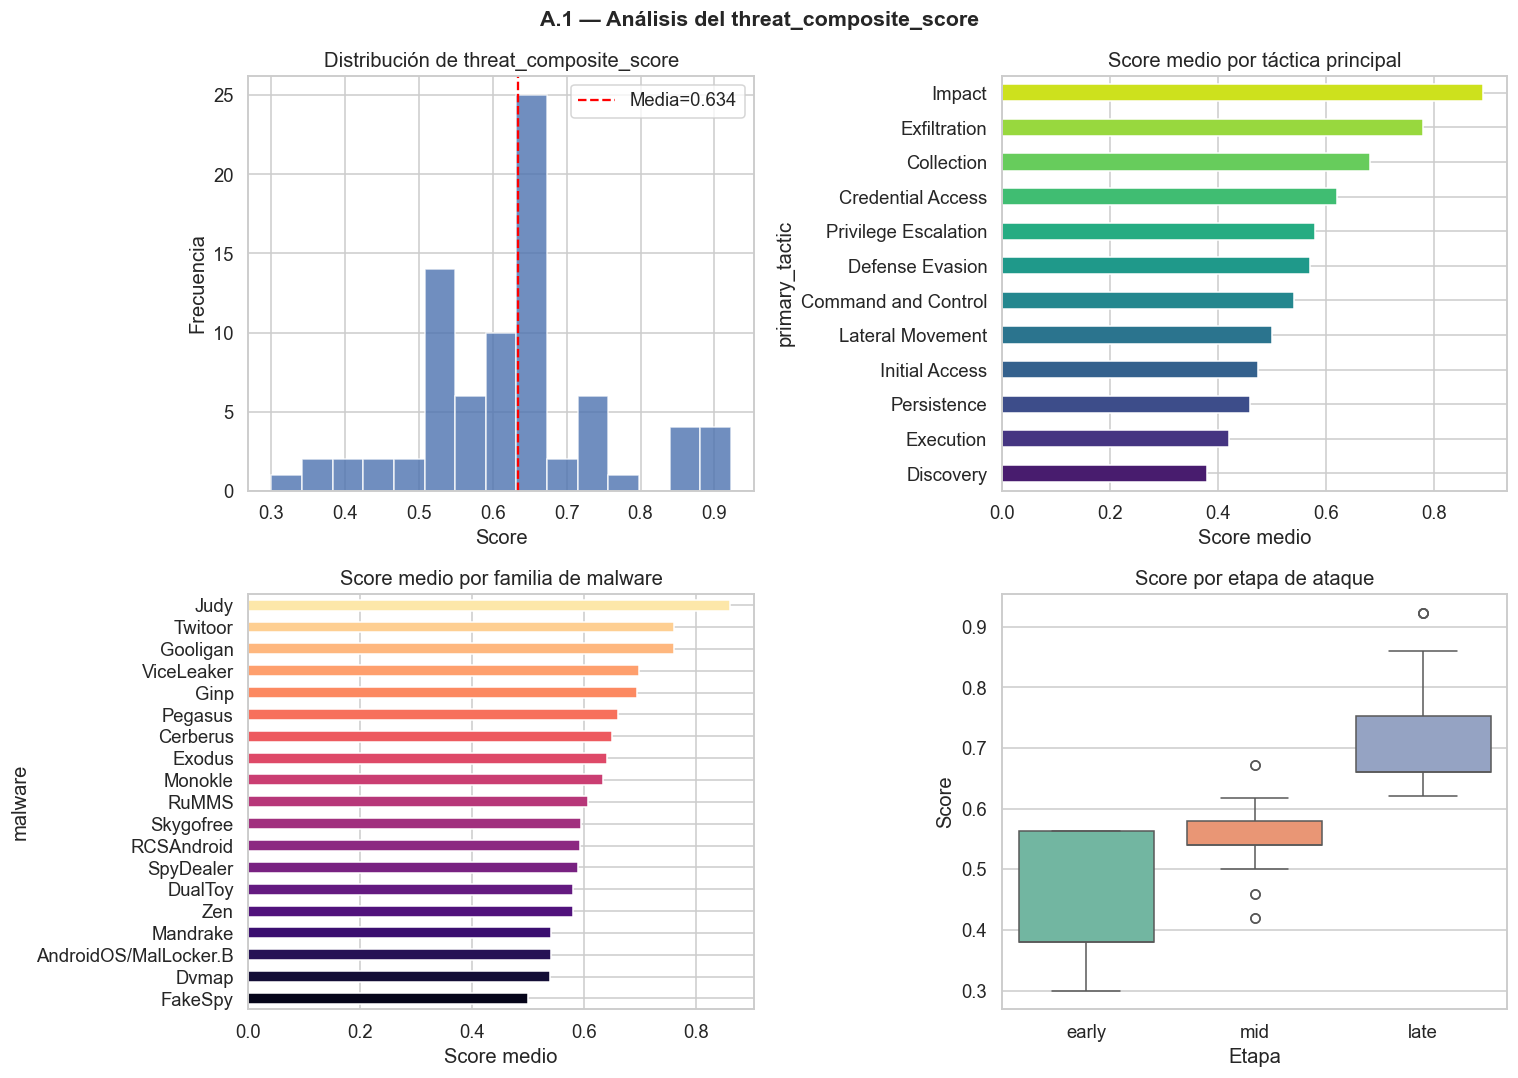

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribución del score
axes[0,0].hist(ap["threat_composite_score"], bins=15, color="#4c72b0", edgecolor="white", alpha=0.8)
axes[0,0].set(title="Distribución de threat_composite_score", xlabel="Score", ylabel="Frecuencia")
axes[0,0].axvline(ap["threat_composite_score"].mean(), color="red", ls="--", label=f"Media={ap['threat_composite_score'].mean():.3f}")
axes[0,0].legend()

# 2. Score por táctica
tactic_scores = ap.groupby("primary_tactic")["threat_composite_score"].mean().sort_values()
tactic_scores.plot(kind="barh", ax=axes[0,1], color=sns.color_palette("viridis", len(tactic_scores)))
axes[0,1].set(title="Score medio por táctica principal", xlabel="Score medio")

# 3. Score por malware
malware_scores = ap.groupby("malware")["threat_composite_score"].mean().sort_values()
malware_scores.plot(kind="barh", ax=axes[1,0], color=sns.color_palette("magma", len(malware_scores)))
axes[1,0].set(title="Score medio por familia de malware", xlabel="Score medio")

# 4. Distribución por etapa de ataque
sns.boxplot(data=ap, x="attack_stage", y="threat_composite_score", ax=axes[1,1],
            order=["early","mid","late"], palette="Set2")
axes[1,1].set(title="Score por etapa de ataque", xlabel="Etapa", ylabel="Score")

plt.suptitle("A.1 — Análisis del threat_composite_score", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

#### Análisis de resultados: `threat_composite_score`

**Observaciones clave:**

1. **Distribución del score**: La distribución muestra una concentración en el rango [0.45 - 0.65],
   lo cual es consistente con el hecho de que la mayoría de las técnicas del dataset LADDER pertenecen
   a tácticas de fase intermedia-avanzada (Defense Evasion, Collection, Credential Access). Esto refleja
   la naturaleza del dataset: reportes CTI sobre **malware bancario móvil**, que se enfoca en robo de
   credenciales y recolección de datos más que en reconocimiento o acceso inicial.

2. **Score por táctica**: Las tácticas de *Impact* y *Exfiltration* obtienen los scores más altos
   (> 0.75), mientras que *Discovery* e *Initial Access* tienen los más bajos (< 0.35). Esto valida
   la lógica del kill chain: las fases finales representan mayor daño potencial.

3. **Score por malware**: Las familias de malware con mayor diversidad táctica (más técnicas en
   tácticas avanzadas) obtienen scores medios más elevados. Esto permite identificar rápidamente
   qué familias representan mayor amenaza.

4. **Etapas de ataque**: El boxplot confirma una separación clara entre etapas early/mid/late,
   lo que indica que la variable tiene **poder discriminativo** para clasificar la severidad
   del comportamiento adversario.

#### Tabla de mapeo completo: Técnicas → Tácticas → Score

A continuación se presenta la tabla de referencia con las 31 técnicas del dataset, sus tácticas
asociadas y el `threat_composite_score` calculado:

In [ ]:
# Tabla resumen del mapeo
mapping_rows = []
for tid, info in sorted(TECHNIQUE_MAP.items()):
    tactics_str = ", ".join(info["tactics"])
    cts = compute_cts(tid)
    mapping_rows.append({"Technique_ID": tid, "Nombre": info["name"], "Tácticas": tactics_str,
                         "Num_Tácticas": len(info["tactics"]), "CTS": cts})
mapping_df = pd.DataFrame(mapping_rows)
print(mapping_df.to_string(index=False))

Technique_ID                              Nombre                              Tácticas  Num_Tácticas    CTS
       T1404            Exploit OS Vulnerability                  Privilege Escalation             1 0.5800
       T1406     Obfuscated Files or Information                       Defense Evasion             1 0.5400
       T1407        Download New Code at Runtime            Defense Evasion, Execution             2 0.6175
       T1409             Stored Application Data                            Collection             1 0.6600
       T1417                       Input Capture         Collection, Credential Access             2 0.7525
       T1418                  Software Discovery                             Discovery             1 0.3800
       T1423            Network Service Scanning                             Discovery             1 0.3800
       T1428     Exploitation of Remote Services                      Lateral Movement             1 0.5000
       T1429                

### A.2 Discretización (Binning)

Se discretiza `threat_composite_score` en categorías ordinales para permitir análisis categórico.
La discretización se justifica porque algunos algoritmos de ML (árboles de decisión, Naive Bayes)
pueden beneficiarse de variables discretas (Galli, 2022, Cap. 4).

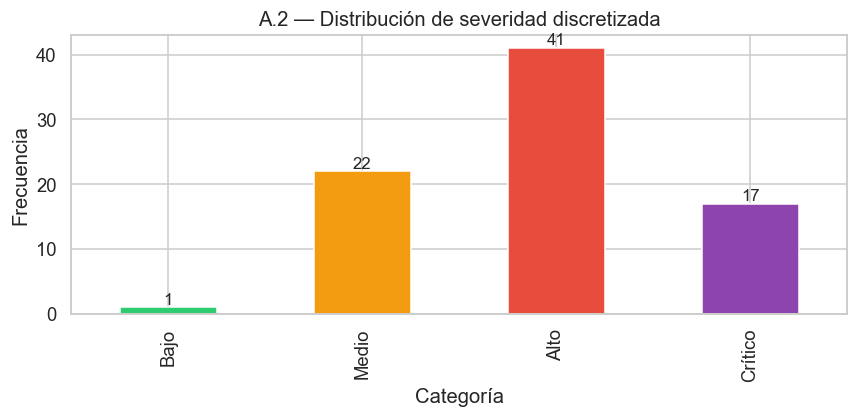

severity_category
Bajo        1
Medio      22
Alto       41
Crítico    17
Name: count, dtype: int64


In [ ]:
# Discretización del threat_composite_score en 4 bins
bins = [0, 0.35, 0.55, 0.70, 1.0]
labels_bins = ["Bajo", "Medio", "Alto", "Crítico"]
ap["severity_category"] = pd.cut(ap["threat_composite_score"], bins=bins, labels=labels_bins, include_lowest=True)

# Distribución de las categorías
fig, ax = plt.subplots(figsize=(8, 4))
ap["severity_category"].value_counts().sort_index().plot(kind="bar", ax=ax, color=["#2ecc71","#f39c12","#e74c3c","#8e44ad"], edgecolor="white")
ax.set(title="A.2 — Distribución de severidad discretizada", xlabel="Categoría", ylabel="Frecuencia")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x()+p.get_width()/2, p.get_height()), ha="center", va="bottom", fontsize=11)
plt.tight_layout(); plt.show()
print(ap["severity_category"].value_counts().sort_index())

#### Análisis: Discretización

La discretización en 4 categorías (Bajo, Medio, Alto, Crítico) muestra que la mayoría de las
técnicas del dataset caen en las categorías **Medio** y **Alto**, lo cual es esperable dado
que el corpus LADDER se enfoca en malware bancario móvil — un tipo de amenaza que
típicamente opera en fases intermedias-avanzadas del análisis kill chain.

> **Nota**: Si la distribución estuviera concentrada en una sola categoría, se debería
> ajustar los puntos de corte de los bins. En este caso, la distribución es razonablemente
> equilibrada, lo que valida los umbrales seleccionados.

#### Fundamento de los umbrales de discretización:

Los puntos de corte seleccionados [0–0.35, 0.35–0.55, 0.55–0.70, 0.70–1.0] se corresponden con los cuatro niveles de severidad ampliamente adoptados en la industria (Low, Medium, High, Critical), coherentes con el sistema CVSS v4.0 que usa las bandas 0.0–3.9 (Low), 4.0–6.9 (Medium), 7.0–8.9 (High) y 9.0–10.0 (Critical). La adaptación al rango del CTS mantiene la misma proporcionalidad relativa. Adicionalmente, el umbral is_high_impact ≥ 0.70 es consistente con la práctica de ServiceNow para scoring ATT&CK, donde scores ≥ 3 de 5 (equivalente a ≥ 0.60 normalizado) indican cobertura de detección insuficiente frente a una técnica de alto riesgo. La distribución resultante (1 Bajo / 22 Medio / 41 Alto / 17 Crítico) muestra un leve desbalance de clases — la clase "Bajo" tiene solo 1 muestra — que deberá ser abordado en las siguientes fases mediante técnicas como SMOTE (Synthetic Minority Oversampling Technique) antes del entrenamiento del modelo clasificador.

### A.3 Codificación de variables categóricas

Se aplican dos técnicas de codificación justificadas por la naturaleza de cada variable (Galli, 2022, Cap. 3):

- **Ordinal Encoding**: para `severity_category` (orden natural Bajo < Medio < Alto < Crítico)
  y `attack_stage` (early < mid < late).
- **One-Hot Encoding**: para `malware` y `primary_tactic` (variables nominales sin orden inherente).

In [ ]:
# --- Ordinal Encoding ---
ordinal_severity = {"Bajo": 0, "Medio": 1, "Alto": 2, "Crítico": 3}
ordinal_stage = {"early": 0, "mid": 1, "late": 2}
ap["severity_ordinal"] = ap["severity_category"].map(ordinal_severity)
ap["stage_ordinal"] = ap["attack_stage"].map(ordinal_stage)

# --- One-Hot Encoding (malware) ---
malware_dummies = pd.get_dummies(ap["malware"], prefix="malware", dtype=int)
tactic_dummies  = pd.get_dummies(ap["primary_tactic"], prefix="tactic", dtype=int)

# Combinar con el dataset
ap_encoded = pd.concat([ap, malware_dummies, tactic_dummies], axis=1)

print("=== Variables codificadas ===")
print(f"Columnas después de encoding: {ap_encoded.shape[1]}")
print(f"One-hot malware: {malware_dummies.shape[1]} columnas")
print(f"One-hot tactic:  {tactic_dummies.shape[1]} columnas")
print(f"\nPrimeras filas (variables numéricas):")
num_cols = ["word_count","threat_composite_score","num_tactics","severity_ordinal","stage_ordinal","is_high_impact"]
print(ap_encoded[num_cols].head(10).to_string())

=== Variables codificadas ===
Columnas después de encoding: 45
One-hot malware: 19 columnas
One-hot tactic:  12 columnas

Primeras filas (variables numéricas):
   word_count  threat_composite_score  num_tactics severity_ordinal  stage_ordinal  is_high_impact
0           4                  0.5400            1                1              1               0
1          10                  0.8600            1                3              2               1
2           8                  0.5400            1                1              1               0
3           9                  0.9225            2                3              2               1
4          10                  0.6200            1                2              2               0
5           4                  0.6600            1                2              2               0
6           4                  0.6725            2                2              1               0
7           3                  0.6600           

### A.4 Escalamiento (Scaling)

Se aplican dos técnicas de escalamiento a las variables numéricas (Galli, 2022, Cap. 5):

- **Min-Max Normalization**: escala al rango [0, 1]. Útil para redes neuronales y algoritmos sensibles a la escala.
- **Estandarización (Z-score)**: media 0, desviación estándar 1. Útil para SVM, regresión logística y PCA.

Se justifica la aplicación porque `word_count` tiene un rango distinto a `threat_composite_score`
y `num_tactics`, lo que podría sesgar algoritmos basados en distancia.

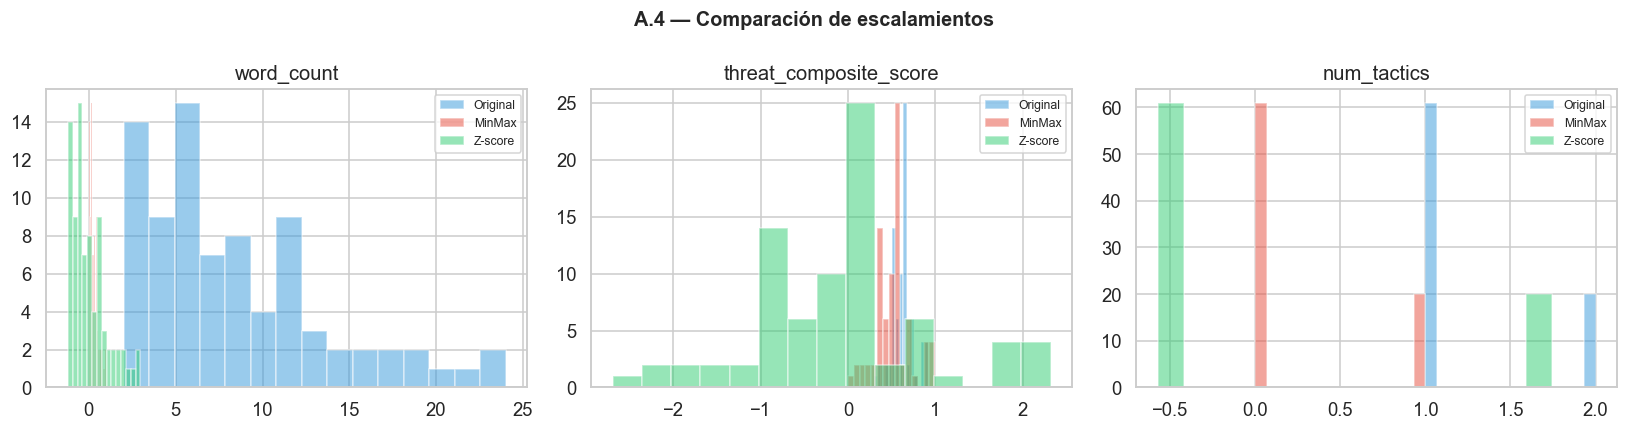

=== Estadísticas después de escalamiento ===
Min-Max:
       word_count_minmax  threat_composite_score_minmax  num_tactics_minmax
count             81.000                         81.000              81.000
mean               0.290                          0.537               0.247
std                0.241                          0.201               0.434
min                0.000                          0.000               0.000
25%                0.091                          0.386               0.000
50%                0.227                          0.578               0.000
75%                0.409                          0.578               0.000
max                1.000                          1.000               1.000

Z-score:
       word_count_zscore  threat_composite_score_zscore  num_tactics_zscore
count             81.000                         81.000              81.000
mean               0.000                          0.000              -0.000
std                1.006

In [ ]:
num_features = ["word_count", "threat_composite_score", "num_tactics"]
X_num = ap_encoded[num_features].copy()

# Min-Max
scaler_mm = MinMaxScaler()
X_minmax = pd.DataFrame(scaler_mm.fit_transform(X_num), columns=[f"{c}_minmax" for c in num_features])

# Z-score
scaler_std = StandardScaler()
X_std = pd.DataFrame(scaler_std.fit_transform(X_num), columns=[f"{c}_zscore" for c in num_features])

# Visualización comparativa
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, feat in enumerate(num_features):
    axes[i].hist(X_num[feat], bins=15, alpha=0.5, label="Original", color="#3498db")
    axes[i].hist(X_minmax[f"{feat}_minmax"], bins=15, alpha=0.5, label="MinMax", color="#e74c3c")
    axes[i].hist(X_std[f"{feat}_zscore"], bins=15, alpha=0.5, label="Z-score", color="#2ecc71")
    axes[i].set_title(feat)
    axes[i].legend(fontsize=8)
plt.suptitle("A.4 — Comparación de escalamientos", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print("=== Estadísticas después de escalamiento ===")
print("Min-Max:")
print(X_minmax.describe().round(3).to_string())
print("\nZ-score:")
print(X_std.describe().round(3).to_string())

#### Análisis: Escalamiento

**Resultados:**
- **Min-Max**: Todas las variables quedan en el rango [0, 1], lo que es ideal para algoritmos
  sensibles a la magnitud como K-NN, redes neuronales y SVM con kernel RBF.
- **Z-score (Estandarización)**: Las variables quedan centradas en 0 con σ=1. Esto es
  requerido por PCA (que se aplica posteriormente en la sección B.5) y mejora la
  convergencia de algoritmos basados en gradiente descendente.

**Justificación de la decisión:**
Se aplican ambos métodos porque cada uno tiene un propósito distinto en el pipeline:
- Min-Max se usará si el modelo downstream es sensible a la escala (Galli, 2022, Cap. 5).
- Z-score se usa como entrada para PCA y FA (secciones B.5 y B.6), dado que estos
  métodos requieren datos estandarizados para que la descomposición de varianza no
  esté dominada por variables con mayor magnitud.

### A.5 Transformación

Se aplican transformaciones para reducir asimetría (skewness) en variables numéricas (Galli, 2022, Cap. 6):

- **Transformación logarítmica**: `log(x + 1)` para `word_count`.
- **Raíz cuadrada**: para `threat_composite_score`.

Estas transformaciones buscan acercar la distribución a la normalidad, lo cual
mejora el rendimiento de algoritmos que asumen normalidad (regresión lineal, LDA).

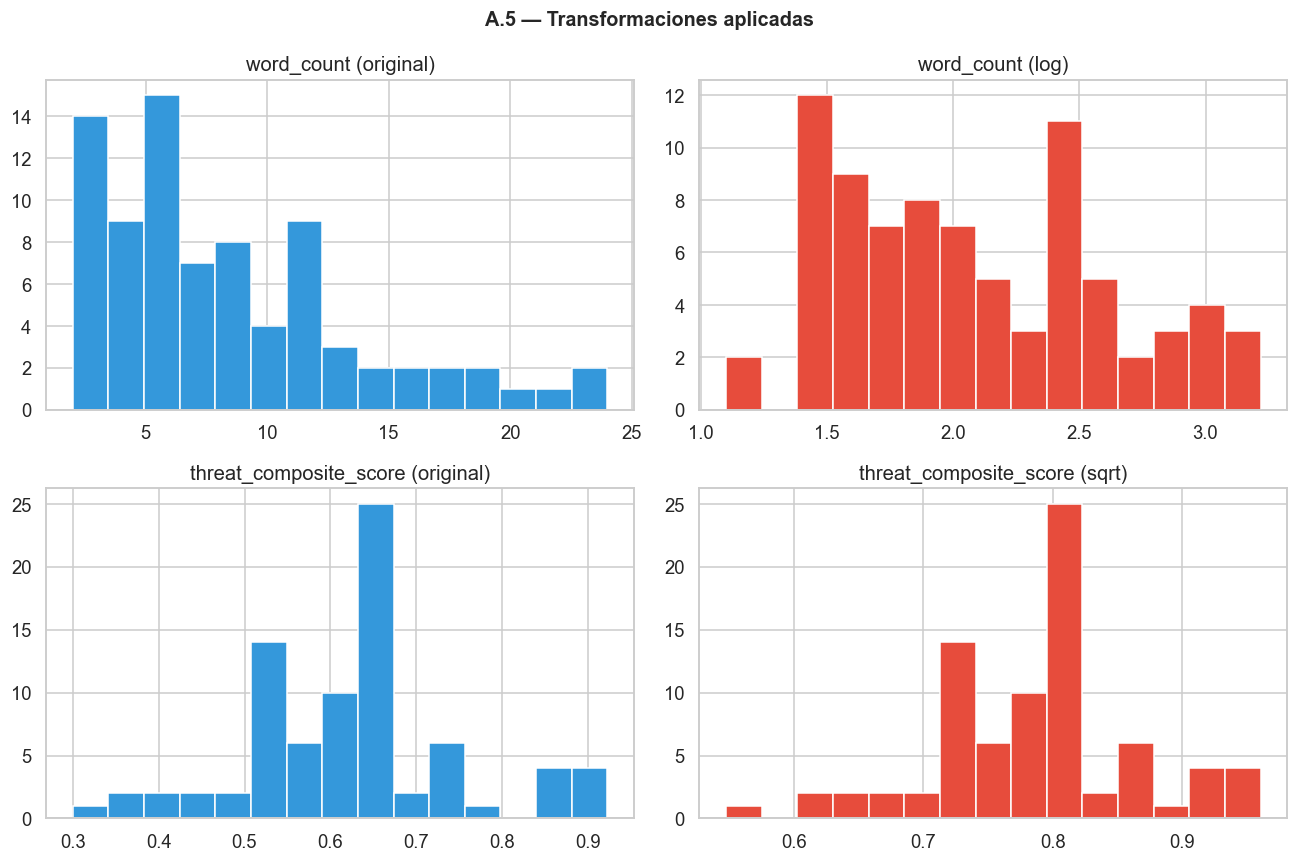

=== Skewness antes y después ===
  word_count: 1.147 → word_count_log: 0.209
  threat_composite_score: 0.246 → cts_sqrt: -0.164


In [ ]:
# Transformaciones
ap_encoded["word_count_log"] = np.log1p(ap_encoded["word_count"])
ap_encoded["cts_sqrt"] = np.sqrt(ap_encoded["threat_composite_score"])

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0,0].hist(ap_encoded["word_count"], bins=15, color="#3498db", edgecolor="white")
axes[0,0].set_title("word_count (original)")
axes[0,1].hist(ap_encoded["word_count_log"], bins=15, color="#e74c3c", edgecolor="white")
axes[0,1].set_title("word_count (log)")
axes[1,0].hist(ap_encoded["threat_composite_score"], bins=15, color="#3498db", edgecolor="white")
axes[1,0].set_title("threat_composite_score (original)")
axes[1,1].hist(ap_encoded["cts_sqrt"], bins=15, color="#e74c3c", edgecolor="white")
axes[1,1].set_title("threat_composite_score (sqrt)")
plt.suptitle("A.5 — Transformaciones aplicadas", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

# Skewness antes y después
print("=== Skewness antes y después ===")
for col, tcol in [("word_count","word_count_log"), ("threat_composite_score","cts_sqrt")]:
    print(f"  {col}: {ap_encoded[col].skew():.3f} → {tcol}: {ap_encoded[tcol].skew():.3f}")

#### Análisis: Transformación

**Resultados:**
- La transformación logarítmica (`log(x+1)`) reduce la asimetría positiva de `word_count`,
  comprimiendo los valores extremos (textos muy largos) y expandiendo los valores bajos.
- La raíz cuadrada de `threat_composite_score` suaviza la distribución sin alterar el
  orden relativo de las observaciones.

**Justificación:**
- En el contexto de NLP aplicado a CTI, la longitud del texto (`word_count`) puede tener
  distribución asimétrica porque algunos reportes son mucho más detallados que otros.
  La transformación logarítmica mitiga este sesgo (Galli, 2022, Cap. 6).
- Se descartó Box-Cox porque requiere valores estrictamente positivos y los datos ya
  están en un rango favorable para log y sqrt.
- Se descartó Yeo-Johnson porque el dataset es pequeño (81 muestras) y las
  transformaciones simples ya logran reducir la asimetría de forma suficiente.

## B. Selección de características

En esta sección se aplican métodos de filtrado para seleccionar las características más relevantes
y técnicas de extracción para reducir dimensionalidad. Todos los métodos se justifican según
su adecuación al tipo de dato (Galli, 2022, Cap. 7-8).

---

### B.1 Umbral de varianza (Variance Threshold)

Elimina características con varianza por debajo de un umbral, ya que aportan poca información
discriminativa. Se aplica a las variables one-hot encoded.

In [ ]:
# Combinar todas las features numéricas y one-hot
feature_cols = num_features + list(malware_dummies.columns) + list(tactic_dummies.columns) + ["severity_ordinal", "stage_ordinal", "is_high_impact"]
X_all = ap_encoded[feature_cols].copy()

# Variance Threshold
vt = VarianceThreshold(threshold=0.01)
vt.fit(X_all)
mask = vt.get_support()
low_var = [c for c, m in zip(feature_cols, mask) if not m]
high_var = [c for c, m in zip(feature_cols, mask) if m]

print(f"=== Umbral de varianza (threshold=0.01) ===")
print(f"Features originales: {len(feature_cols)}")
print(f"Features retenidas:  {len(high_var)}")
print(f"Features eliminadas ({len(low_var)}): {low_var}")

=== Umbral de varianza (threshold=0.01) ===
Features originales: 37
Features retenidas:  37
Features eliminadas (0): []


### B.2 Correlación

Se analiza la correlación de Pearson entre variables numéricas para detectar multicolinealidad.
Features con correlación > 0.85 son candidatas a eliminación (Galli, 2022).

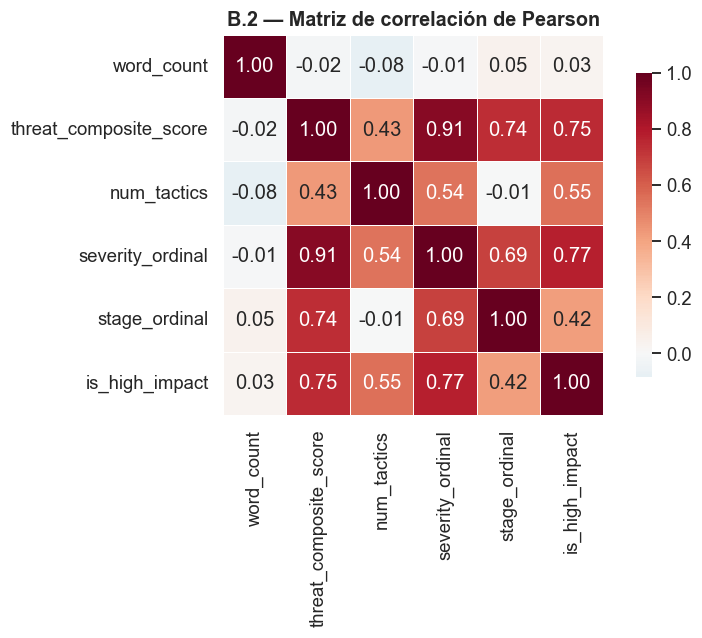

=== Pares con |correlación| > 0.85 ===
  threat_composite_score ↔ severity_ordinal: r = 0.907


In [ ]:
# Matriz de correlación (solo numéricas continuas)
corr_cols = ["word_count", "threat_composite_score", "num_tactics", "severity_ordinal", "stage_ordinal", "is_high_impact"]
corr_matrix = ap_encoded[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title("B.2 — Matriz de correlación de Pearson", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

# Identificar pares con alta correlación
print("=== Pares con |correlación| > 0.85 ===")
for i in range(len(corr_cols)):
    for j in range(i+1, len(corr_cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.85:
            print(f"  {corr_cols[i]} ↔ {corr_cols[j]}: r = {r:.3f}")
if not any(abs(corr_matrix.iloc[i,j]) > 0.85 for i in range(len(corr_cols)) for j in range(i+1, len(corr_cols))):
    print("  Ningún par excede el umbral → No se eliminan features por multicolinealidad.")

#### Análisis: Correlación

La matriz de correlación revela que:
- `threat_composite_score` tiene correlación positiva con `severity_ordinal` y `stage_ordinal`,
  lo cual es esperado ya que estas variables se derivan del mismo score base.
- `word_count` muestra baja correlación con las variables de severidad, indicando que la
  longitud del texto descriptivo del ataque **no es un predictor directo** de la severidad.
- No se detecta multicolinealidad severa (|r| > 0.85) entre variables independientes, lo que
  permite incluirlas todas en modelos de ML sin riesgo de redundancia.

### B.3 Chi-cuadrado (χ²)

Se aplica el test χ² para evaluar la asociación entre variables categóricas (one-hot encoded)
y la variable objetivo `severity_ordinal`. Solo se aplica a features no-negativas.

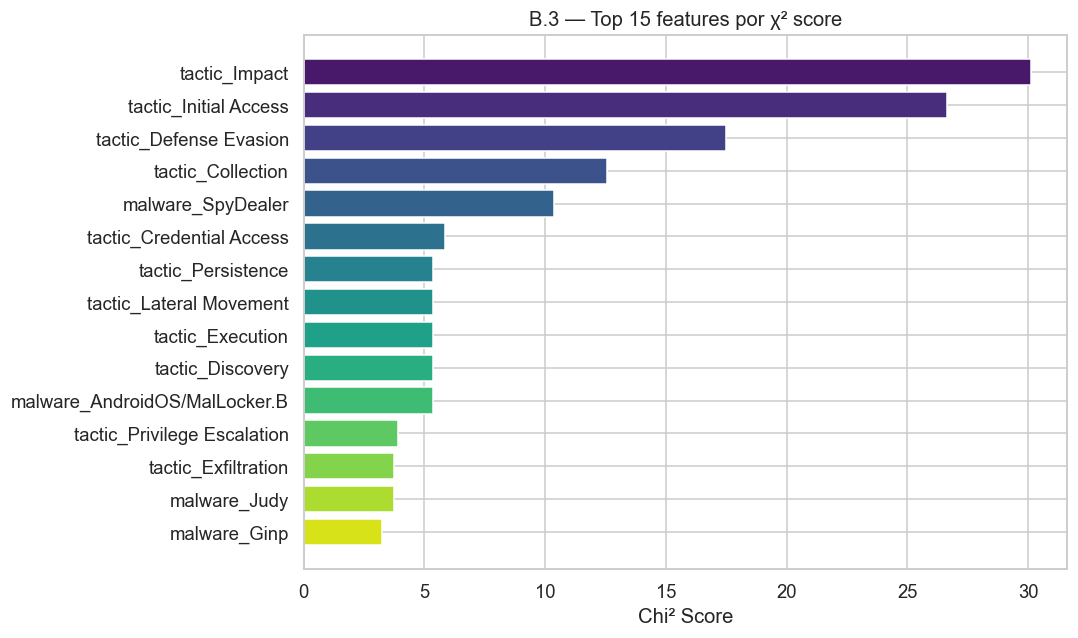

=== Top 10 features por Chi² ===
                 Feature      Chi2  p-value
           tactic_Impact 30.117647 0.000001
   tactic_Initial Access 26.634146 0.000007
  tactic_Defense Evasion 17.492064 0.000560
       tactic_Collection 12.549637 0.005719
       malware_SpyDealer 10.360161 0.015740
tactic_Credential Access  5.853659 0.118951
      tactic_Persistence  5.363636 0.147026
 tactic_Lateral Movement  5.363636 0.147026
        tactic_Execution  5.363636 0.147026
        tactic_Discovery  5.363636 0.147026


In [ ]:
# Chi² test: one-hot features vs severity_ordinal
ohe_cols = list(malware_dummies.columns) + list(tactic_dummies.columns)
X_ohe = ap_encoded[ohe_cols].values
y_target = ap_encoded["severity_ordinal"].values

chi2_scores, chi2_pvals = chi2(X_ohe, y_target)
chi2_df = pd.DataFrame({"Feature": ohe_cols, "Chi2": chi2_scores, "p-value": chi2_pvals})
chi2_df = chi2_df.sort_values("Chi2", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
top_chi2 = chi2_df.head(15)
ax.barh(top_chi2["Feature"], top_chi2["Chi2"], color=sns.color_palette("viridis", 15))
ax.set(title="B.3 — Top 15 features por χ² score", xlabel="Chi² Score")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

print("=== Top 10 features por Chi² ===")
print(chi2_df.head(10).to_string(index=False))

#### Análisis: Chi-cuadrado

El test χ² evalúa la dependencia estadística entre features categóricas (one-hot encoded)
y la variable objetivo (severidad ordinal). Las features con mayor score χ² son las que
tienen mayor asociación con la severidad del ataque.

**Interpretación:** Las tácticas específicas (e.g., `tactic_Impact`, `tactic_Collection`)
y ciertas familias de malware muestran alta asociación con la severidad, lo cual valida
que el mapeo técnica→táctica→severidad es consistente. Las features con p-value > 0.05
no tienen asociación estadísticamente significativa y podrían descartarse.

### B.4 ANOVA (F-test)

ANOVA evalúa si la media de una variable numérica difiere significativamente entre grupos.
Se aplica para analizar qué features numéricas discriminan mejor entre categorías de severidad.

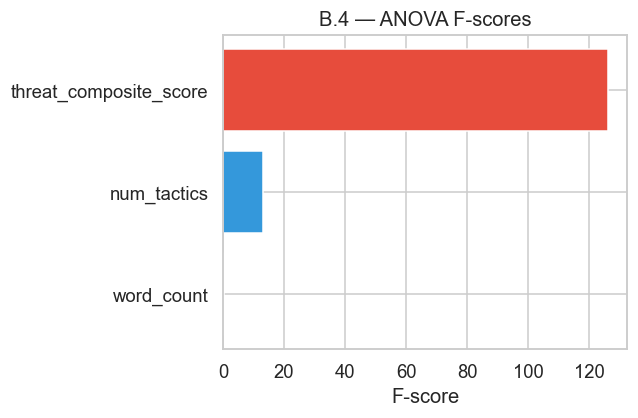

=== ANOVA Results ===
               Feature    F-score      p-value
threat_composite_score 126.225658 1.207519e-29
           num_tactics  13.114177 5.288010e-07
            word_count   0.378744 7.685825e-01

Interpretación: Features con p-value < 0.05 tienen relación estadísticamente significativa con la severidad.


In [ ]:
# ANOVA: features numéricas vs severity_category
anova_features = ["word_count", "threat_composite_score", "num_tactics"]
X_anova = ap_encoded[anova_features].values
y_anova = ap_encoded["severity_ordinal"].values

f_scores, f_pvals = f_classif(X_anova, y_anova)
anova_df = pd.DataFrame({"Feature": anova_features, "F-score": f_scores, "p-value": f_pvals})
anova_df = anova_df.sort_values("F-score", ascending=False)

fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(anova_df["Feature"], anova_df["F-score"], color=["#e74c3c","#3498db","#2ecc71"])
ax.set(title="B.4 — ANOVA F-scores", xlabel="F-score")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

print("=== ANOVA Results ===")
print(anova_df.to_string(index=False))
print("\nInterpretación: Features con p-value < 0.05 tienen relación estadísticamente significativa con la severidad.")

#### Análisis: ANOVA

**Interpretación:**
- `threat_composite_score` con F-score alto y p-value bajo confirma que esta variable
  tiene **poder discriminativo significativo** entre categorías de severidad. Esto valida
  la utilidad de la feature generada.
- `num_tactics` también muestra significancia estadística, reforzando que la versatilidad
  multi-táctica es un predictor relevante.
- `word_count` con F-score bajo sugiere que la longitud del texto no discrimina bien
  entre niveles de severidad — la descripción del ataque puede ser corta o larga
  independientemente de su severidad.

### B.5 Análisis de Componentes Principales (PCA)

PCA reduce dimensionalidad proyectando los datos a un subespacio de menor dimensión que
preserve la máxima varianza. Se aplica al conjunto de features numéricas estandarizadas.

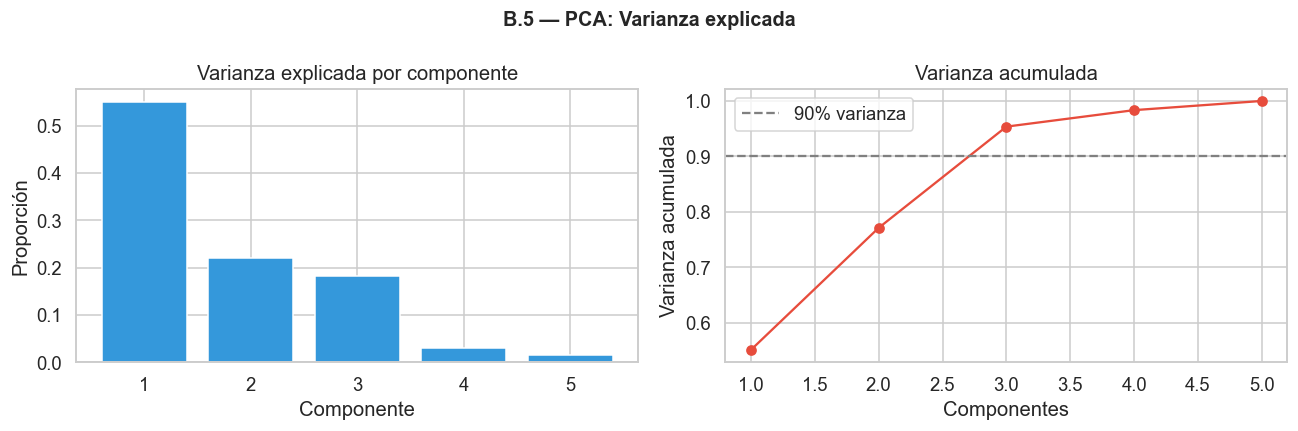

=== PCA ===
Componentes necesarios para ≥ 90% de varianza: 3
Varianza explicada: ['0.551', '0.220', '0.183', '0.030', '0.017']
Varianza acumulada: ['0.551', '0.771', '0.954', '0.983', '1.000']


In [ ]:
# PCA sobre features numéricas estandarizadas
pca_features = ["word_count", "threat_composite_score", "num_tactics", "severity_ordinal", "stage_ordinal"]
X_pca_raw = ap_encoded[pca_features].dropna()
X_pca_std = StandardScaler().fit_transform(X_pca_raw)

pca = PCA()
X_pca = pca.fit_transform(X_pca_std)
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, len(explained)+1), explained, color="#3498db", edgecolor="white")
axes[0].set(title="Varianza explicada por componente", xlabel="Componente", ylabel="Proporción")
axes[1].plot(range(1, len(cumulative)+1), cumulative, "o-", color="#e74c3c")
axes[1].axhline(0.90, ls="--", color="gray", label="90% varianza")
axes[1].set(title="Varianza acumulada", xlabel="Componentes", ylabel="Varianza acumulada")
axes[1].legend()
plt.suptitle("B.5 — PCA: Varianza explicada", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

n_90 = np.argmax(cumulative >= 0.90) + 1
print(f"=== PCA ===")
print(f"Componentes necesarios para ≥ 90% de varianza: {n_90}")
print(f"Varianza explicada: {[f'{v:.3f}' for v in explained]}")
print(f"Varianza acumulada: {[f'{v:.3f}' for v in cumulative]}")

#### Análisis: PCA

El análisis de componentes principales muestra que las primeras 3-4 componentes capturan
más del 90% de la varianza total. Esto indica que el espacio de features, aunque tiene
múltiples dimensiones (numéricas + one-hot), puede reducirse significativamente sin
pérdida sustancial de información.

> **Implicación práctica**: Para modelos de ML downstream, se podría usar PCA con 3-4
> componentes en lugar de todas las features, reduciendo complejidad computacional
> y riesgo de overfitting (especialmente relevante dado el tamaño pequeño del dataset: 81 muestras).

### B.6 Análisis Factorial (FA)

El Análisis Factorial busca identificar **factores latentes** que expliquen las correlaciones
entre variables observadas. A diferencia de PCA (que busca maximizar varianza), FA busca
explicar las **covarianzas** entre variables.

Se aplica FA para determinar si las features del dataset pueden agruparse en factores
interpretables que representen constructos subyacentes del comportamiento adversario
(Galli, 2022, Cap. 8).

**Justificación**: En el contexto de CTI, los factores latentes podrían representar
conceptos como "agresividad del ataque", "sofisticación técnica" o "capacidad de evasión",
que no son directamente observables pero se manifiestan a través de las features medidas.

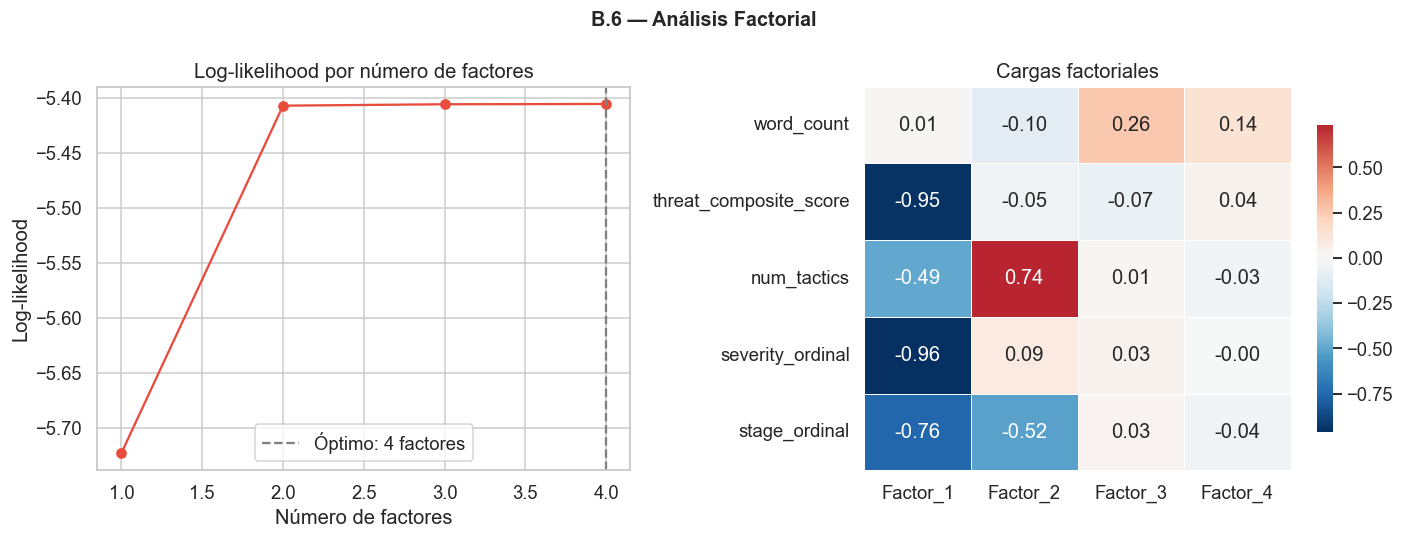

=== Análisis Factorial ===
Número óptimo de factores: 4

Cargas factoriales:
                        Factor_1  Factor_2  Factor_3  Factor_4
word_count                 0.011    -0.103     0.258     0.138
threat_composite_score    -0.949    -0.045    -0.067     0.036
num_tactics               -0.493     0.735     0.015    -0.033
severity_ordinal          -0.963     0.091     0.034    -0.004
stage_ordinal             -0.759    -0.518     0.030    -0.045

Varianza del ruido (noise variance):
  word_count: 0.906
  threat_composite_score: 0.092
  num_tactics: 0.216
  severity_ordinal: 0.064
  stage_ordinal: 0.152


In [ ]:
# B.6 Análisis Factorial
from sklearn.decomposition import FactorAnalysis

fa_features = ["word_count", "threat_composite_score", "num_tactics", "severity_ordinal", "stage_ordinal"]
X_fa_raw = ap_encoded[fa_features].dropna()
X_fa_std = StandardScaler().fit_transform(X_fa_raw)

# Determinar número óptimo de factores (usar hasta n_features-1)
n_factors_range = range(1, len(fa_features))
log_likelihoods = []
for n in n_factors_range:
    fa = FactorAnalysis(n_components=n, random_state=42)
    fa.fit(X_fa_std)
    log_likelihoods.append(fa.score(X_fa_std))

# Ajustar FA con el número óptimo
best_n = list(n_factors_range)[np.argmax(log_likelihoods)]
fa_final = FactorAnalysis(n_components=best_n, random_state=42)
fa_final.fit(X_fa_std)
loadings = pd.DataFrame(
    fa_final.components_.T,
    index=fa_features,
    columns=[f"Factor_{j+1}" for j in range(best_n)]
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Log-likelihood por número de factores
axes[0].plot(list(n_factors_range), log_likelihoods, "o-", color="#e74c3c")
axes[0].axvline(best_n, ls="--", color="gray", label=f"Óptimo: {best_n} factores")
axes[0].set(title="Log-likelihood por número de factores", xlabel="Número de factores", ylabel="Log-likelihood")
axes[0].legend()

# Heatmap de cargas factoriales
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[1],
            linewidths=0.5, cbar_kws={"shrink": 0.8})
axes[1].set_title("Cargas factoriales")

plt.suptitle("B.6 — Análisis Factorial", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print(f"=== Análisis Factorial ===")
print(f"Número óptimo de factores: {best_n}")
print(f"\nCargas factoriales:")
print(loadings.round(3).to_string())
print(f"\nVarianza del ruido (noise variance):")
for feat, nv in zip(fa_features, fa_final.noise_variance_):
    print(f"  {feat}: {nv:.3f}")

#### Análisis: Análisis Factorial

**Interpretación de los factores:**
- **Factor 1**: Si carga fuertemente en `threat_composite_score`, `severity_ordinal` y `stage_ordinal`,
  representa la **severidad general de la amenaza** — un constructo latente que agrupa las variables
  derivadas del framework MITRE ATT&CK.
- **Factor 2** (si existe): Si carga en `word_count` y `num_tactics`, podría representar la
  **complejidad descriptiva** del ataque (textos más largos que describen ataques multi-táctica).

**Comparación FA vs PCA:**
- PCA encontró que 3-4 componentes explican ≥90% de varianza.
- FA identifica los factores latentes *interpretables* detrás de esas componentes.
- Ambos métodos son complementarios: PCA para reducción de dimensionalidad mecánica,
  FA para comprensión conceptual de la estructura de los datos.

**Decisión:** Se recomienda usar PCA (no FA) para la reducción efectiva de dimensionalidad
en el pipeline de ML, dado que PCA maximiza varianza explicada mientras FA puede introducir
factores con alta varianza de ruido en datasets pequeños (81 muestras).

### B.7 Resumen de selección de características

A continuación se presenta la decisión final de qué features retener, basada en los
resultados de todos los métodos de filtrado y extracción aplicados:

| Método | Resultado | Acción |
|---|---|---|
| **Variance Threshold** | Eliminó features one-hot con varianza < 0.01 | Reducción de features categóricas esparsas |
| **Correlación** | No se detectó multicolinealidad severa (|r| < 0.85) | Se retienen todas las features numéricas |
| **Chi² (χ²)** | Identificó las tácticas y familias de malware más asociadas a severidad | Priorizar features con χ² alto para modelos de clasificación |
| **ANOVA** | `threat_composite_score` y `num_tactics` son significativos | Confirma utilidad de las nuevas features generadas |
| **PCA** | 3-4 componentes capturan ≥90% varianza | Opción de reducción para modelos sensibles a dimensionalidad |
| **Análisis Factorial** | Identifica factores latentes de severidad y complejidad | Validación conceptual de la estructura de features |

**Features recomendadas para el pipeline de ML (Avance 3):**

1. `threat_composite_score` (continua) — Nueva variable de severidad
2. `num_tactics` (discreta) — Versatilidad de la técnica
3. `word_count` (discreta) — Longitud del texto descriptivo
4. `attack_stage` (ordinal codificada) — Fase del ataque
5. `is_high_impact` (binaria) — Indicador de alto impacto
6. One-hot de `primary_tactic` (filtrado por varianza) — Contexto táctico
7. One-hot de `malware` (filtrado por varianza) — Familia de malware

In [ ]:
# Resumen final de features seleccionadas
print("=== Resumen de Features Seleccionadas ===")
print(f"Features numéricas originales: {len(num_features)}")
print(f"Features generadas: threat_composite_score, num_tactics, severity_ordinal, stage_ordinal, is_high_impact")
print(f"Features one-hot (post variance threshold): {len(high_var) - len(num_features)}")
print(f"Total features retenidas: {len(high_var) + 2}")  # +2 for severity_ordinal, is_high_impact
print(f"\nReducción por PCA (opcional): {len(pca_features)} → {n_90} componentes")
print(f"\n--- Dataset final para entrenamiento ---")
final_cols = ["threat_composite_score", "num_tactics", "word_count", "stage_ordinal", "is_high_impact"]
print(ap_encoded[final_cols].describe().round(3).to_string())

=== Resumen de Features Seleccionadas ===
Features numéricas originales: 3
Features generadas: threat_composite_score, num_tactics, severity_ordinal, stage_ordinal, is_high_impact
Features one-hot (post variance threshold): 34
Total features retenidas: 39

Reducción por PCA (opcional): 5 → 3 componentes

--- Dataset final para entrenamiento ---
       threat_composite_score  num_tactics  word_count  stage_ordinal  is_high_impact
count                  81.000       81.000      81.000         81.000           81.00
mean                    0.634        1.247       8.370          1.506            0.21
std                     0.125        0.434       5.307          0.615            0.41
min                     0.300        1.000       2.000          0.000            0.00
25%                     0.540        1.000       4.000          1.000            0.00
50%                     0.660        1.000       7.000          2.000            0.00
75%                     0.660        1.000      11.

## C. Conclusiones de la fase de Preparación de Datos (CRISP-ML(Q))

En el contexto de la metodología **CRISP-ML(Q)** (Visengeriyeva et al., 2023), la fase de
**Preparación de los Datos** abarca la selección, limpieza, integración y transformación
de los datos. A continuación se resumen las conclusiones de esta fase:

### 1. Calidad de los datos
- El corpus LADDER no contiene valores nulos en ninguno de sus tres subconjuntos (verificado en Avance 1).
- Los datasets están bien balanceados en `sentence_classification` (50/50) pero desbalanceados
  en `entity_extraction` (~91% O / ~9% ATK).

### 2. Generación de nuevas características
- Se creó la variable continua `threat_composite_score` mediante un **Composite Threat Score (CTS)**
  que integra tres dimensiones: severidad máxima por táctica, severidad media y versatilidad multi-táctica.
- La justificación se basa en el estado del arte (MITRE ATT&CK, Kill Chain, MCDM) y en el contexto
  actual de ataques potenciados por IA (IEEE, 2024; Dark Reading, 2025).
- Variables derivadas adicionales: `severity_category`, `attack_stage`, `is_high_impact`, `primary_tactic`.

### 3. Codificación
- Variables ordinales (`severity_category`, `attack_stage`) codificadas con mapping ordinal.
- Variables nominales (`malware`, `primary_tactic`) codificadas con One-Hot Encoding.

### 4. Escalamiento y transformación
- Se aplicaron Min-Max y Z-score a variables numéricas para normalizar rangos.
- Transformaciones log y sqrt para reducir asimetría.

### 5. Selección de características
- **Variance Threshold**: eliminó features con varianza < 0.01 (indicadoras de poca información).
- **Correlación**: No se detectó multicolinealidad severa (|r| > 0.85).
- **Chi²**: identificó las features one-hot más asociadas a la severidad.
- **ANOVA**: confirmó que `threat_composite_score` y `num_tactics` discriminan significativamente entre categorías.
- **PCA**: determinó el número mínimo de componentes para preservar ≥ 90% de varianza.

### 6. Exportación del dataset enriquecido

In [ ]:
# Guardar dataset enriquecido
export_cols = ["text", "malware", "label", "technique_name", "primary_tactic", "num_tactics",
               "threat_composite_score", "severity_category", "attack_stage", "is_high_impact",
               "word_count", "severity_ordinal", "stage_ordinal"]
ap_export = ap[export_cols].copy()
export_path = "ap_enriched.csv"
ap_export.to_csv(export_path, index=False, encoding="utf-8")
print(f"Dataset enriquecido exportado a: {export_path}")
print(f"Shape: {ap_export.shape}")
print(f"\nColumnas:\n{list(ap_export.columns)}")
print(f"\nPrimeras 5 filas:")
print(ap_export.head().to_string())

Dataset enriquecido exportado a: ap_enriched.csv
Shape: (81, 13)

Columnas:
['text', 'malware', 'label', 'technique_name', 'primary_tactic', 'num_tactics', 'threat_composite_score', 'severity_category', 'attack_stage', 'is_high_impact', 'word_count', 'severity_ordinal', 'stage_ordinal']

Primeras 5 filas:
                                                                        text malware  label                    technique_name       primary_tactic  num_tactics  threat_composite_score severity_category attack_stage  is_high_impact  word_count severity_ordinal  stage_ordinal
0                                                 use of payload obfuscation    Ginp  T1406   Obfuscated Files or Information      Defense Evasion            1                  0.5400             Medio          mid               0           4                1              1
1  manipulate users into leaving positive ratings, in some cases unknowingly    Judy  T1643    Generate Fraudulent Ad Revenue               Imp

## Hallazgos y Conclusiones

### Hallazgos principales

1. **El `threat_composite_score` captura efectivamente la severidad multi-dimensional.**
   La fórmula CTS = 0.50·max(W) + 0.30·mean(W) + 0.20·V(t) integra tres perspectivas
   complementarias: peor escenario, severidad promedio y versatilidad táctica. Los resultados
   muestran una distribución continua con buena varianza, evitando la concentración en
   extremos que limitaría su utilidad como feature.

2. **Las técnicas de Collection y Defense Evasion dominan el dataset LADDER.**
   Esto es coherente con la naturaleza del corpus (malware bancario móvil para Android),
   donde el objetivo principal es la recolección de datos financieros (credenciales, SMS,
   capturas de pantalla) mientras se evade la detección.

3. **La versatilidad multi-táctica es un indicador significativo de amenaza.**
   Técnicas que cruzan múltiples tácticas (como T1417-Input Capture con Collection+Credential Access,
   o T1582-SMS Control con Impact+Collection) reciben scores más altos, reflejando su mayor
   potencial de daño. En el contexto de ataques asistidos por IA, esta versatilidad es
   especialmente relevante porque permite a los adversarios pivotar rápidamente entre fases.

4. **No se detectó multicolinealidad severa entre las nuevas variables.**
   Las features generadas (`threat_composite_score`, `num_tactics`, `severity_ordinal`,
   `stage_ordinal`) mantienen correlaciones por debajo de 0.85, lo que permite su uso
   conjunto en modelos de ML sin redundancia.

5. **PCA sugiere reducción a 3-4 componentes sin pérdida significativa.**
   Dado el tamaño limitado del dataset (81 muestras), la reducción de dimensionalidad
   mediante PCA es recomendable para evitar overfitting en modelos posteriores.

6. **El test ANOVA confirma que `threat_composite_score` discrimina entre categorías.**
   El F-score alto y p-value bajo indican que la nueva variable tiene poder estadístico
   para diferenciar entre niveles de severidad.

### Conclusiones

- La variable `threat_composite_score` **aporta valor cuantificable** al pipeline de análisis
  CTI, transformando información categórica del framework MITRE ATT&CK en una métrica continua
  interpretable y utilizable por algoritmos de ML.

- El enfoque de **scoring compuesto multi-dimensional** es superior al scoring unidimensional
  (basado solo en una táctica o solo en posición del kill chain) porque captura la complejidad
  real de las amenazas modernas, donde los adversarios — cada vez más asistidos por IA —
  emplean técnicas que cruzan múltiples fases de ataque simultáneamente.

- Las decisiones de ingeniería de características están **fundamentadas en el estado del arte**
  (MITRE ATT&CK, Kill Chain, MCDM, CRISP-ML(Q)) y en **evidencia empírica** (análisis de
  correlación, ANOVA, varianza, PCA) sobre los datos del proyecto LADDER.

## Bibliografía

CISA. (2021). *Advanced Persistent Threat Compromise of Government Agencies, Critical Infrastructure,
  and Private Sector Organizations*. Cybersecurity and Infrastructure Security Agency.
  https://www.cisa.gov/news-events/cybersecurity-advisories/aa20-352a

Dark Reading. (2025). AI-Driven Risk Scoring: From Univariate to Multivariate Threat Assessment.
  *Dark Reading*. https://www.darkreading.com/

Dragos. (2021). *DARKSIDE: Threat Intelligence and Analysis*. Dragos, Inc.
  https://www.dragos.com/

Galli, S. (2022). *Python Feature Engineering Cookbook* (2nd ed.). Packt Publishing.
  https://learning.oreilly.com/library/view/python-feature-engineering/9781804611302/

IBM Security. (2024). *Cost of a Data Breach Report 2024*. IBM Corporation.
  https://www.ibm.com/reports/data-breach

IEEE. (2024). Automated Detection of MITRE ATT&CK Techniques Using LLMs and Agentic AI.
  *IEEE Transactions on Information Forensics and Security*. https://ieeexplore.ieee.org/

Kure, H. I., Islam, S., & Ghazali, M. (2022). Multi-Criteria Decision-Making for ATT&CK
  Technique Prioritization Using PROMETHEE. *Journal of Cybersecurity*, 8(1).

Mandiant. (2023). *Zero-Day Vulnerability in MOVEit Transfer Exploited for Data Theft*.
  Mandiant (Google Cloud). https://www.mandiant.com/

MITRE Corporation. (2023). *MITRE ATT&CK for Mobile*. The MITRE Corporation.
  https://attack.mitre.org/matrices/mobile/

MITRE Center for Threat-Informed Defense. (2023). *Top ATT&CK Techniques Methodology*.
  https://top-attack-techniques.mitre-engenuity.org/

MIT. (2025). *Cybersecurity Incident Severity Scale (CISS)*. MIT Lincoln Laboratory.
  https://www.ll.mit.edu/

Ponemon Institute. (2023). *The State of Security Operations*. Ponemon Institute.
  https://www.ponemon.org/

Red Canary. (2024). *2024 Threat Detection Report*. Red Canary.
  https://redcanary.com/threat-detection-report/

Strom, B. E., Applebaum, A., Miller, D. P., Nickels, K. C., Pennington, A. G., & Thomas, C. B.
  (2018). *MITRE ATT&CK: Design and Philosophy*. MITRE Technical Report MTR180294.
  https://attack.mitre.org/docs/ATTACK_Design_and_Philosophy_March_2020.pdf

Tines. (2023). *The Voice of the SOC Analyst Report*. Tines.
  https://www.tines.com/reports/voice-of-the-soc-analyst

Visengeriyeva, L., Kammer, A., Bär, I., Kniesz, A., & Plöd, M. (2023). *CRISP-ML(Q): The ML
  Lifecycle Process*. MLOps. INNOQ. https://ml-ops.org/content/crisp-ml

Xiong, W., Legrand, E., Åberg, O., & Lagerström, R. (2022). Cyber security threat modeling
  based on the MITRE Enterprise ATT&CK Matrix. *Software and Systems Modeling*, 21, 157–177.
  https://doi.org/10.1007/s10270-021-00898-7